# 📊 Moving Average Analysis - Reliance Stock

## Objective
To analyze stock price trends using Moving Average techniques and understand smoothing of time series data.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv("Reliance.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-11-18,463.799988,465.649994,454.975006,456.000000,436.671021,5142766.0
1,2015-11-19,459.450012,469.350006,458.625000,467.375000,447.563873,5569752.0
2,2015-11-20,467.000000,476.399994,462.774994,473.424988,453.357422,5167930.0
3,2015-11-23,475.000000,478.950012,473.100006,476.875000,456.661224,4800026.0
4,2015-11-24,476.500000,485.799988,475.524994,483.850006,463.340515,6768886.0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1233 non-null   object 
 1   Open       1232 non-null   float64
 2   High       1232 non-null   float64
 3   Low        1232 non-null   float64
 4   Close      1232 non-null   float64
 5   Adj Close  1232 non-null   float64
 6   Volume     1232 non-null   float64
dtypes: float64(6), object(1)
memory usage: 67.6+ KB


In [28]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1.232000e+03
mean,1036.035414,1048.479285,1023.015573,1035.164502,1024.471417,9.981743e+06
std,463.719976,469.906022,455.946191,462.301697,466.231636,7.603435e+06
min,459.000000,465.649994,444.049988,453.274994,434.061554,1.283997e+06
25%,551.925003,561.393768,546.000000,553.049988,540.720703,5.555522e+06
50%,959.099976,972.474976,946.675018,960.949982,946.843903,7.560520e+06
75%,1309.024963,1321.649963,1292.274963,1308.337494,1298.972321,1.140781e+07
max,2325.000000,2369.350098,2310.550049,2324.550049,2324.550049,6.523004e+07


In [29]:
df.shape

(1233, 7)

In [30]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [31]:
df.isnull().sum()

Date         0
Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

In [32]:
df.fillna(method="ffill", inplace=True)

C:\Users\TEJASVINI\AppData\Local\Temp\ipykernel_440988\173857299.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [33]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [34]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

Date column is converted into datetime format and set as index for time series analysis.

In [35]:
#Select closing price
df['Close'].head()

Date
2015-11-18    456.000000
2015-11-19    467.375000
2015-11-20    473.424988
2015-11-23    476.875000
2015-11-24    483.850006
Name: Close, dtype: float64

In [36]:
df['SMA_10'] = df['Close'].rolling(window=10).mean()

In [37]:
df['SMA_30'] = df['Close'].rolling(window=30).mean()

In [38]:
df[['Close', 'SMA_10', 'SMA_30']].tail()

,Close,SMA_10,SMA_30
Date,,,
2020-11-10,2084.550049,1985.329992,2121.285002
2020-11-11,1997.199951,1983.904992,2113.023332
2020-11-12,1980.000000,1979.214990,2104.544995
2020-11-13,1996.400024,1973.404992,2096.916663
2020-11-17,1993.250000,1984.984997,2089.618331


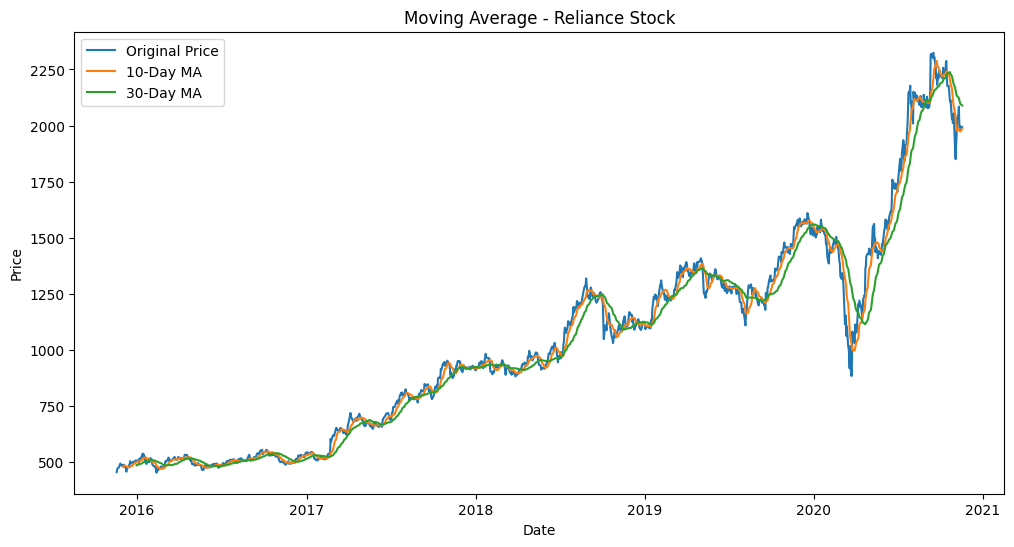

In [39]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Original Price')
plt.plot(df['SMA_10'], label='10-Day MA')
plt.plot(df['SMA_30'], label='30-Day MA')

plt.title("Moving Average - Reliance Stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

### 🔹 Observations

- Moving averages smooth out price fluctuations  
- 10-day MA reacts faster to price changes  
- 30-day MA shows long-term trend  
- Helps identify trend direction (uptrend/downtrend)  

## ✅ Conclusion

Moving Average is an effective technique for analyzing time series data.  
It helps in identifying trends and reducing noise in stock price movements.